In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('retail_sales_dataset.csv')
display(df.head())

print("\n--- Data Info ---")
df.info()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100



--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


=== Descriptive Statistics for Numerical Columns ===


,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


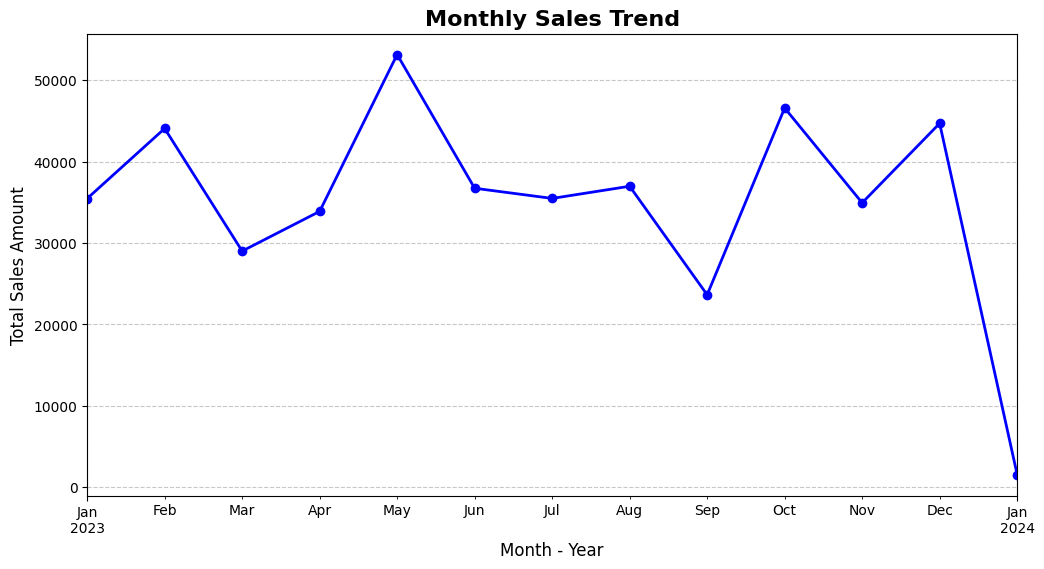

In [2]:
# 1. Convert the 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# 2. Generate Descriptive Statistics
print("=== Descriptive Statistics for Numerical Columns ===")
display(df.describe())

# 3. Time Series Analysis - Monthly Sales Trend
# Extract Year-Month for easier grouping
df['Month-Year'] = df['Date'].dt.to_period('M')

# Group total sales by month
monthly_sales = df.groupby('Month-Year')['Total Amount'].sum()

# Plot the Line Chart
plt.figure(figsize=(12, 6))
monthly_sales.plot(kind='line', marker='o', color='b', linewidth=2)
plt.title('Monthly Sales Trend', fontsize=16, fontweight='bold')
plt.xlabel('Month - Year', fontsize=12)
plt.ylabel('Total Sales Amount', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

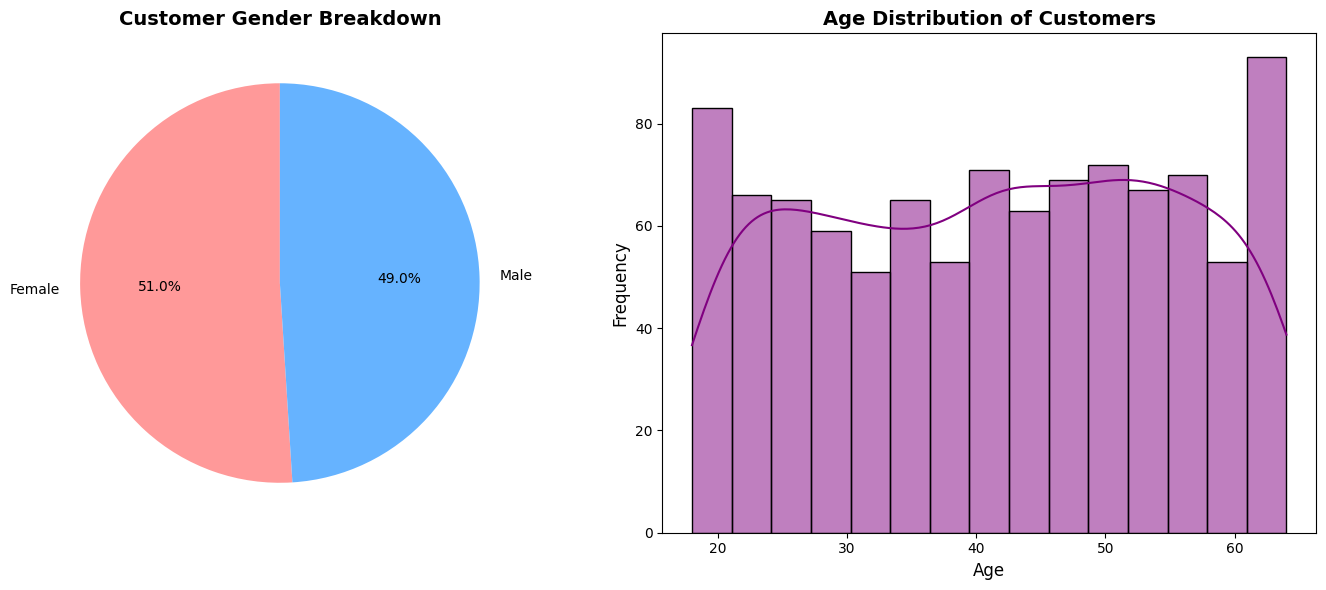

In [3]:
# 4. Customer Demographics Analysis
plt.figure(figsize=(14, 6))

# Plot 1: Gender Breakdown (Pie Chart)
plt.subplot(1, 2, 1)
gender_counts = df['Gender'].value_counts()
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
plt.title('Customer Gender Breakdown', fontweight='bold', fontsize=14)

# Plot 2: Age Distribution (Histogram)
plt.subplot(1, 2, 2)
sns.histplot(df['Age'], bins=15, kde=True, color='purple')
plt.title('Age Distribution of Customers', fontweight='bold', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2092/3733718621.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_revenue.index, y=category_revenue.values, palette='viridis')


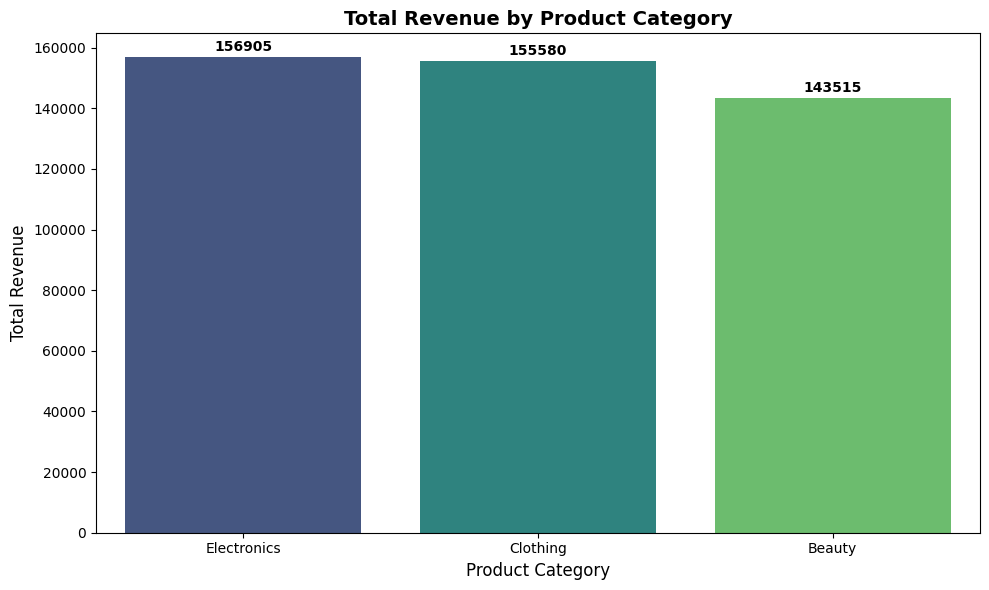

In [4]:
# 5. Product Analysis: Revenue by Product Category
plt.figure(figsize=(10, 6))

# Calculate total revenue per product category
category_revenue = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

# Plot the Bar Chart
sns.barplot(x=category_revenue.index, y=category_revenue.values, palette='viridis')
plt.title('Total Revenue by Product Category', fontweight='bold', fontsize=14)
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)

# Add values on top of bars
for i, v in enumerate(category_revenue.values):
    plt.text(i, v + 2000, str(int(v)), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()